In [1]:

from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
import numpy as np
import pydicom
from scipy import ndimage

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

from metrics import run_analysis_on_path

pylinac_version: 3.44.0
date_of_analysis: 2026-06-16T13:33:36.189235
warnings: []
x_metrics:
Field Size Calculation by FWHM (mm): 100.12800000000001
Flatness Calculation by Variance (%): 2.184286983094733
Flatness Calculation by Ratio (IEC) (%): 103.0102496229493
Flatness Calculation by CAX Variance: 0.49866941500407636
Flatness Calculation by CAX Ratio: 1.0487163315848576
Symmetry Calculation by CAX Point Difference (%): -1.9997231152609638
Symmetry Calculation by Point Ratio (IEC 976) (%): 101.45511868311759
Symmetry Calculation by Area (%): 0.9853672642371698
Field Width (mm): 100.10128101629608
y_metrics:
Field Size Calculation by FWHM (mm): 100.12800000000001
Flatness Calculation by Variance (%): 1.679534781720975
Flatness Calculation by Ratio (IEC) (%): 102.22123090648986
Flatness Calculation by CAX Variance: 0.4811487640172899
Flatness Calculation by CAX Ratio: 1.0377332369364243
Symmetry Calculation by CAX Point Difference (%): 0.0
Symmetry Calculation by Point Ratio (IEC 976) 

In [2]:
def generate_dicom_using_layers(file_out_name, layers):
    as1200 = AS1200Image(sid=1000)
    for layer in layers:
        as1200.add_layer(layer)
    as1200.generate_dicom(file_out_name=file_out_name, gantry_angle=0)
    plt.imsave(file_out_name.with_suffix('.png'), as1200.image)
    return as1200

dir_path = Path(".")
dir_path = dir_path / "Test"
dir_path.mkdir(parents=True, exist_ok=True)

In [ ]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(5, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom_using_layers(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

In [ ]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(100, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom_using_layers(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

In [ ]:
field_layers = [
layers.FilteredFieldLayer(
    field_size_mm=(100, 100),
    alpha=0.9,
),
layers.SlopeLayer(
    slope_x=0.02,
    slope_y=0.0
),
layers.GaussianFilterLayer()
]
file_path = dir_path / "symmetry_x_sloped_10x10.dcm"
simulator_instance = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(simulator_instance.image)
print(simulator_instance.image.max())

In [ ]:
simulator_instance = AS1200Image(sid=1000) # hardcoded to get consistent pixel size for calc of column offset
dpmm = 25.4 / simulator_instance.pixel_size
print(dpmm)
simulator_instance.pixel_size

In [ ]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200.image)
print(as1200.image.max())

pylinac_version: 3.44.0
date_of_analysis: 2026-06-16T15:29:25.886321
warnings: []
x_metrics:
Field Size Calculation by FWHM (mm): 100.12800000000001
Flatness Calculation by Variance (%): 2.7509481668773703
Flatness Calculation by Ratio (IEC) (%): 103.92855285736572
Flatness Calculation by CAX Variance: 0.5167752147175588
Flatness Calculation by CAX Ratio: 1.0600819948623472
Symmetry Calculation by CAX Point Difference (%): -4.059524118425491
Symmetry Calculation by Point Ratio (IEC 976) (%): 102.97542377247669
Symmetry Calculation by Area (%): 1.9997487397382896
Field Width (mm): 100.04445984629429
y_metrics:
Field Size Calculation by FWHM (mm): 100.12800000000001
Flatness Calculation by Variance (%): 2.7509481668773703
Flatness Calculation by Ratio (IEC) (%): 103.92855285736572
Flatness Calculation by CAX Variance: 0.5167752147175588
Flatness Calculation by CAX Ratio: 1.0600819948623472
Symmetry Calculation by CAX Point Difference (%): -4.059524118425491
Symmetry Calculation by Point 

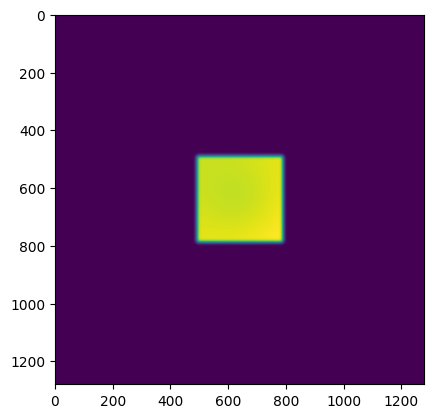

In [ ]:
file_path = dir_path / "symmetry_two_percent_x_and_y_area_10x10.dcm"
field_layers = [
layers.FilteredFieldLayer(
    field_size_mm=(100, 100),
    alpha=0.5,
),
layers.SlopeLayer(
    slope_x=0.2371,
    slope_y=0.2371
),
layers.GaussianFilterLayer()
]
simulator_instance = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(simulator_instance.image)
print(run_analysis_on_path(file_path))

In [ ]:
field_layers = [
    layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_imperfect_fff_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200)